# CS 376 Project: Evaluating LLM Response Quality Across Typologically Diverse Languages
### By: Anna St. Clair and Alayna Smith

# CS 376 Project: Evaluating LLM Response Quality Across Typologically Diverse Languages
### By: Anna St. Clair and Alayna Smith

**What we're doing:**
We are prompting a single LLM with the same questions in 3 to 5 typologically distinct languages, chosen to represent different grammatical word orders such as SVO (English), SOV (Japanese, Korean, Bengali), and VSO (Arabic). Using the openai/MMMLU multilingual benchmark dataset, we evaluate whether response quality varies meaningfully across languages despite the prompts being semantically equivalent. If differences emerge, we investigate potential causes through tokenization analysis (e.g., token count per prompt, vocabulary coverage in the model's tokenizer), morphological complexity, and training data representation.

**Which course objectives it demonstrates:**

 - Tuneable Machines: We take a deeper look at how the model processes different languages by examining the tokenizer's vocabulary coverage and how differently structured sentences are segmented. This connects directly to understanding data flow and what the model is "actually doing" before it even begins generating a response.
 - Optimization Games: We will frame this as a benchmarking problem, selecting evaluation metrics appropriate for multilingual QA (such as accuracy on closed-form questions or similarity scores for open-ended ones), and reason about what the numbers do and do not capture about real-world multilingual performance.
 - OG-Eval-Experiment: We run a controlled multi-language evaluation comparing model accuracy across scripts and word orders.
 - LLM-Eval: We reflect on the strengths and limitations of exact-match scoring for MCQ, including how shuffling answer positions and tracking INVALID responses reveals richer failure modes.

**Additional self-defined objective:**
Understanding cross-lingual bias in LLMs, specifically how underrepresentation in training data or tokenizer design may produce systematically lower-quality outputs for certain language families.

**How we'll know if it's going well:**
 - We can run prompts in all target languages and collect model outputs without major technical blockers.
 - We have a consistent, reproducible evaluation metric across languages.
 - Initial results show some variance across languages, giving us something meaningful to analyze and explain, rather than uniform performance.
 - We can find at least one concrete explanation (e.g., token fertility differences, bytes-per-character, vocabulary coverage gaps) that plausibly accounts for an observed performance gap.

**Why it matters:**
LLMs are increasingly deployed in multilingual contexts, but most benchmarks and most development resources are English-centric. If a model answers the same question better in English than in Turkish or Arabic, it may have real consequences for who benefits from AI tools and who does not. Understanding whether and why these gaps exist is a meaningful step toward more equitable AI systems.


## Section 0 — Preamble & Imports <a id='section-0'></a>

Install and import all dependencies. We use:
- `openai` for API calls (also used to talk to vLLM's OpenAI-compatible endpoint)
- `datasets` (Hugging Face) for loading M-MMLU
- `tiktoken` for tokenization analysis
- `pandas`, `numpy`, `scipy` for data manipulation and statistics
- `matplotlib`, `seaborn` for visualization
"""

In [ ]:
# Install dependencies (safe to re-run)
import subprocess, sys

REQUIRED = [
    "openai>=1.0.0",
    "datasets",
    "tiktoken",
    "pandas",
    "numpy",
    "scipy",
    "matplotlib",
    "seaborn",
]

for pkg in REQUIRED:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All dependencies installed.")

All dependencies installed.


In [ ]:
import os
import re
import time
import csv
import math
import random
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import tiktoken
from datasets import load_dataset
from openai import OpenAI

print("Imports successful.")

Imports successful.


"""---
## Section 1 — Configuration <a id='section-1'></a>

All experiment parameters live here. To replicate with different settings:
- **Add a language:** Edit only the `LANGUAGES` dict below and add the correct `mmlu_code` (the Hugging Face config name, e.g. `ZH_CN` for Mandarin Chinese).
- **Change subjects:** Edit `MMLU_SUBJECTS` list.
- **Adjust sample size:** Edit `SAMPLE_SIZE`.

### vLLM setup
We use Calvin's on-campus vLLM server instead of GPT-4o to eliminate cost and rate-limit concerns.
The server exposes an OpenAI-compatible API, so we just swap the `base_url`.
See: https://cs.calvin.edu/courses/cs/108/26sp/units/13/lab/
"""

In [ ]:
# ---------------------------------------------------------------------------
# vLLM / MODEL CONFIG
# Points to the Calvin on-campus Qwen server via OpenAI-compatible API.
# No rate limiting needed — we're not paying per token.
# ---------------------------------------------------------------------------
VLLM_BASE_URL = "https://vllm.thoughtful-ai.com/v1"
VLLM_API_KEY  = "dummy"   # vLLM doesn't require a real key; set any non-empty string

client = OpenAI(api_key=VLLM_API_KEY, base_url=VLLM_BASE_URL)

# Check which models are available on the server
available_models = client.models.list()
print("Available models on vLLM server:")
for m in available_models.data:
    print(f"  {m.id}")

# Set to the Qwen model served on the Calvin vLLM instance.
# Adjust the string below to match what `available_models` printed above.
MODEL = "Qwen/Qwen3.5-9B"

# ---------------------------------------------------------------------------
# PUBLISHED MMLU BENCHMARKS (for sanity-checking our English accuracy)
# Source: official model cards / Open LLM Leaderboard
# These are overall MMLU scores; our single-subject score may differ.
# ---------------------------------------------------------------------------
PUBLISHED_MMLU_SCORES = {
    "Qwen/Qwen3.5-9B": 0.911,   # approx; check model card for exact
    # Add more models here as you test them
}

Available models on vLLM server:
  Qwen/Qwen3.5-9B


In [ ]:
# ---------------------------------------------------------------------------
# LANGUAGE CONFIGURATION
# ---------------------------------------------------------------------------
LANGUAGES = {
    "English": {"order": "SVO", "mmlu_code": "default"},
    "Japanese": {"order": "SOV", "mmlu_code": "JA_JP"},
    "Arabic":  {"order": "VSO", "mmlu_code": "AR_XY"},
    "Korean": {"order": "SOV", "mmlu_code": "KO_KR"},
    "Bengali":  {"order": "SOV", "mmlu_code": "BN_BD"},
    "French":   {"order": "SVO", "mmlu_code": "FR_FR"},
    "Swahili":  {"order": "SVO", "mmlu_code": "SW_KE"},
    "Mandarin": {"order": "SVO", "mmlu_code": "ZH_CN"},
}

# ---------------------------------------------------------------------------
# DATASET PARAMETERS
# CHANGE: MMLU_SUBJECTS is now a list so we can test across multiple subjects.
# CHANGE: SAMPLE_SIZE raised now that we're not paying per token via vLLM.
# ---------------------------------------------------------------------------
MMLU_SUBJECTS = [
    "high_school_geography",
    "high_school_biology",
    "high_school_mathematics",
]
SAMPLE_SIZE   = 500                       # questions per language per subject
DATASET_ID    = "openai/MMMLU"
RESULTS_DIR   = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

# No delay needed — on-campus vLLM server, not rate-limited
API_CALL_DELAY = 0.0

# Colour palette: one colour per language
LANG_COLORS = {
    "English":  "#4C72B0",
    "Japanese": "#DD8452",
    "Arabic":   "#55A868",
    "Korean":   "#BB0A1E",
    "Bengali":  "#E377C2",
    "French":   "#9467BD",
    "Swahili":  "#17BECF",
    "Mandarin": "#BCB400",
}

print("Configuration loaded.")
print(f"  Model:      {MODEL}")
print(f"  Subjects:   {MMLU_SUBJECTS}")
print(f"  Sample N:   {SAMPLE_SIZE} questions per language per subject")
print(f"  Languages:  {list(LANGUAGES.keys())}")


Configuration loaded.
  Model:      Qwen/Qwen3.5-9B
  Subjects:   ['high_school_geography', 'high_school_biology', 'high_school_mathematics']
  Sample N:   500 questions per language per subject
  Languages:  ['English', 'Japanese', 'Arabic', 'Korean', 'Bengali', 'French', 'Swahili', 'Mandarin']


"""---
## Section 2 — Dataset Loading & Alignment Verification <a id='section-2'></a>

We load `openai/MMMLU` from Hugging Face. Each language is a separate dataset config.
Every config has the same rows in the same order — question index i in English corresponds
exactly to question index i in Japanese and Arabic.

We verify this alignment by printing the first few questions side-by-side.
"""

In [ ]:
def load_language_data(
    dataset_id: str,
    mmlu_code: str,
    subject: str,
    n: int,
) -> pd.DataFrame:
    """
    Load the first `n` questions for `subject` from the specified language config
    of the openai/MMMLU dataset.

    Returns
    -------
    pd.DataFrame
        Columns: question, A, B, C, D, answer
    """
    ds = load_dataset(dataset_id, mmlu_code, split="test")
    df = ds.to_pandas()
    df = df[df["Subject"] == subject].reset_index(drop=True)

    if len(df) == 0:
        raise ValueError(
            f"No rows found for subject '{subject}' in config '{mmlu_code}'. "
            f"Check the subject name spelling."
        )

    df = df.iloc[:n].copy()
    df = df.rename(columns={"Question": "question", "Answer": "answer"})
    return df[["question", "A", "B", "C", "D", "answer"]]


# Load datasets for all target languages and all subjects
# Structure: language_data[subject][lang_name] = DataFrame
language_data: dict[str, dict[str, pd.DataFrame]] = {}

for subject in MMLU_SUBJECTS:
    language_data[subject] = {}
    for lang_name, cfg in LANGUAGES.items():
        print(f"Loading {lang_name} / {subject} ({cfg['mmlu_code']})...", end=" ")
        df = load_language_data(
            dataset_id=DATASET_ID,
            mmlu_code=cfg["mmlu_code"],
            subject=subject,
            n=SAMPLE_SIZE,
        )
        language_data[subject][lang_name] = df
        print(f"{len(df)} questions loaded.")

print("\nAll language datasets loaded.")

Loading English / high_school_geography (default)... 500 questions loaded.
Loading Japanese / high_school_geography (JA_JP)... 198 questions loaded.
Loading Arabic / high_school_geography (AR_XY)... 198 questions loaded.
Loading Korean / high_school_geography (KO_KR)... 198 questions loaded.
Loading Bengali / high_school_geography (BN_BD)... 198 questions loaded.
Loading French / high_school_geography (FR_FR)... 198 questions loaded.
Loading Swahili / high_school_geography (SW_KE)... 198 questions loaded.
Loading Mandarin / high_school_geography (ZH_CN)... 

Generating test split:   0%|          | 0/14042 [00:00<?, ? examples/s]

198 questions loaded.
Loading English / high_school_biology (default)... 500 questions loaded.
Loading Japanese / high_school_biology (JA_JP)... 310 questions loaded.
Loading Arabic / high_school_biology (AR_XY)... 310 questions loaded.
Loading Korean / high_school_biology (KO_KR)... 310 questions loaded.
Loading Bengali / high_school_biology (BN_BD)... 310 questions loaded.
Loading French / high_school_biology (FR_FR)... 310 questions loaded.
Loading Swahili / high_school_biology (SW_KE)... 310 questions loaded.
Loading Mandarin / high_school_biology (ZH_CN)... 310 questions loaded.
Loading English / high_school_mathematics (default)... 500 questions loaded.
Loading Japanese / high_school_mathematics (JA_JP)... 270 questions loaded.
Loading Arabic / high_school_mathematics (AR_XY)... 270 questions loaded.
Loading Korean / high_school_mathematics (KO_KR)... 270 questions loaded.
Loading Bengali / high_school_mathematics (BN_BD)... 270 questions loaded.
Loading French / high_school_math

In [ ]:
def verify_alignment(language_data_for_subject: dict[str, pd.DataFrame], n_samples: int = 3) -> None:
    """
    Print the first `n_samples` questions side-by-side across all languages to
    confirm that the same question appears at the same index in every language.
    """
    langs = list(language_data_for_subject.keys())
    for i in range(n_samples):
        print(f"{'='*80}")
        print(f"Question index {i}  |  Correct answer: {language_data_for_subject[langs[0]].iloc[i]['answer']}")
        print(f"{'='*80}")
        for lang in langs:
            row = language_data_for_subject[lang].iloc[i]
            q = row["question"][:200] + ("..." if len(row["question"]) > 200 else "")
            print(f"[{lang:>10}]  {q}")
        print()


# Verify alignment on the first subject
print(f"\nAlignment check for subject: {MMLU_SUBJECTS[0]}")
verify_alignment(language_data[MMLU_SUBJECTS[0]], n_samples=2)


def show_example_prompt(language_data_for_subject: dict[str, pd.DataFrame],
                        q_idx: int = 0,
                        compare_langs: list = None) -> None:
    """
    NEW: Print the full formatted prompt exactly as the model receives it,
    side-by-side for the specified languages. Useful for presentations to
    show concretely what the model sees in English vs. Arabic vs. Japanese.

    Also demonstrates the effect of answer-position shuffling.
    """
    if compare_langs is None:
        compare_langs = ["English", "Arabic", "Japanese"]

    print(f"\n{'='*80}")
    print(f"EXAMPLE: What the model actually receives (question index {q_idx})")
    print(f"{'='*80}")

    for lang in compare_langs:
        if lang not in language_data_for_subject:
            continue
        row = language_data_for_subject[lang].iloc[q_idx]
        prompt, _ = build_prompt(row, question_index=q_idx)
        print(f"\n--- [{lang}] ---")
        print(prompt)

    print(f"\n{'='*80}")


Alignment check for subject: high_school_geography
Question index 0  |  Correct answer: B
[   English]  العامل الرئيسي الذي يمنع اقتصادات الكفاف من التقدم اقتصاديًا هو نقص
[  Japanese]  あるものが不足していると、自給自足経済の経済発展を阻む主な要因となるが、そのあるものとはどれか。
[    Arabic]  العامل الرئيسي الذي يمنع اقتصادات الكفاف من التقدم اقتصاديًا هو نقص
[    Korean]  발전이 최저 수준인 경제가 경제적으로 발전하는 것을 가로막는 이유는 다음의 부족 때문이다.
[   Bengali]  জীবিকানির্বাহ অর্থনীতির অর্থনৈতিক অগ্রগতিতে বাধা দেওয়ার প্রধান কারণটি হল
[    French]  Le principal facteur empêchant l’économie de subsistance de progresser économiquement est le manque de
[   Swahili]  Jambo kuu linalozuia uchumi wa kujikimu usiendelee kiuchumi ni ukosefu wa
[  Mandarin]  阻碍自给自足经济在经济上发展的主要因素是缺乏

Question index 1  |  Correct answer: D
[   English]  الاتجاه لزيادة السكان لفترة طويلة بعد تحقيق الخصوبة الاستبدالية يسمى
[  Japanese]  出生率が人口置換水準以下となった後も、長期にわたって人口が増加し続ける傾向を何と呼ぶか。
[    Arabic]  الاتجاه لزيادة السكان لفترة طويلة بعد تحقيق الخصوبة الاستبدالية يسمى
[    Korean]  대체출산이 달성

"""---
## Section 3 — Tokenization Utilities <a id='section-3'></a>

Before running API calls, we define tokenization analysis functions using tiktoken.
Three metrics are computed per prompt, plus a new bytes-per-character metric.

| Metric | Definition | Why it matters |
|--------|-----------|----------------|
| **Token count** | Total tiktoken tokens in the prompt | Directly drives API cost |
| **Token fertility** | Tokens ÷ whitespace-split words | How "expensive" a language is tokenisation-wise |
| **Subword fragmentation rate** | Fraction of tokens that are subword pieces | Captures tokenizer struggle with a given script |
| **Bytes per char** | UTF-8 bytes ÷ character count | NEW: Arabic/CJK chars cost 2–4 bytes vs 1 for ASCII — equity metric |
"""

In [ ]:
# Initialise the tiktoken encoder once (reusing it is faster)
ENCODER = tiktoken.encoding_for_model("gpt-4o")


def tokenize_prompt(text: str) -> dict:
    """
    Compute tokenization metrics for a single prompt string.

    Returns
    -------
    dict with keys:
        token_count (int)
        token_fertility (float)
        subword_frag_rate (float)
        bytes_per_char (float)    — NEW: UTF-8 bytes per Unicode character
        char_count (int)          — NEW
        byte_count (int)          — NEW
    """
    tokens = ENCODER.encode(text)
    token_count = len(tokens)

    words = text.split()
    n_words = max(len(words), 1)
    token_fertility = token_count / n_words

    decoded_tokens = [ENCODER.decode([t]) for t in tokens]

    def is_fragment(tok: str) -> bool:
        if not tok:
            return True
        if tok.startswith(" "):
            return False
        if re.match(r'^[\W\d]+$', tok):
            return True
        return True

    n_fragments = sum(is_fragment(t) for t in decoded_tokens)
    subword_frag_rate = n_fragments / max(token_count, 1)

    # NEW: bytes-per-character metric
    encoded_bytes = text.encode("utf-8")
    byte_count  = len(encoded_bytes)
    char_count  = len(text)
    bytes_per_char = byte_count / max(char_count, 1)

    return {
        "token_count":       token_count,
        "token_fertility":   round(token_fertility, 4),
        "subword_frag_rate": round(subword_frag_rate, 4),
        "bytes_per_char":    round(bytes_per_char, 4),
        "char_count":        char_count,
        "byte_count":        byte_count,
    }


# Quick sanity check
sample_text = "What is the capital of France? A) London B) Paris C) Berlin D) Rome"
print("Tokenization sanity check (English):")
print(tokenize_prompt(sample_text))

arabic_sample = "ما هي عاصمة فرنسا؟ أ) لندن ب) باريس ج) برلين د) روما"
print("\nTokenization sanity check (Arabic):")
print(tokenize_prompt(arabic_sample))


Tokenization sanity check (English):
{'token_count': 19, 'token_fertility': 1.3571, 'subword_frag_rate': 0.3158, 'bytes_per_char': 1.0, 'char_count': 67, 'byte_count': 67}

Tokenization sanity check (Arabic):
{'token_count': 20, 'token_fertility': 1.6667, 'subword_frag_rate': 0.45, 'bytes_per_char': 1.7115, 'char_count': 52, 'byte_count': 89}


"""---
## Section 4 — Prompt Runner <a id='section-4'></a>

Key design decisions:
- **Answer shuffling (NEW):** Answer choices A/B/C/D are shuffled using the question index
  as a random seed. The SAME seed is used across all languages for the same question, so
  cross-language comparisons remain fair. This prevents the model from exploiting positional
  biases (e.g., always guessing A), which is documented in the literature (see
  https://arxiv.org/html/2406.19470v2).
- **Failure mode tracking (NEW):** We distinguish between wrong-letter responses and
  INVALID (non-letter) responses, since these reflect different failure types.
- **Format instruction (NEW):** We explicitly tell the model the output format to reduce
  INVALID responses and isolate language-understanding failures from format failures.
- **No rate limiting:** API_CALL_DELAY = 0.0 since we use the on-campus vLLM server.
"""

In [ ]:
ANSWER_LETTERS = ["A", "B", "C", "D"]


def build_prompt(row: pd.Series, question_index: int) -> tuple[str, dict]:
    """
    Build the full prompt string from a dataset row, with shuffled answer positions.

    The shuffle is seeded by question_index so it is:
      - Deterministic (reproducible)
      - Identical across all languages for the same question (fair comparison)
      - Different for each question (avoids positional memorization)

    Parameters
    ----------
    row : pd.Series
        A single row from a language DataFrame (columns: question, A, B, C, D, answer).
    question_index : int
        The integer index of this question, used as the shuffle seed.

    Returns
    -------
    tuple[str, dict]
        (prompt_string, shuffle_map)
        shuffle_map maps original letter -> new letter position so we can
        remap the correct answer after shuffling.
    """
    rng = random.Random(question_index)  # seeded RNG — same shuffle for every language

    original_choices = {
        "A": row["A"],
        "B": row["B"],
        "C": row["C"],
        "D": row["D"],
    }

    # Shuffle the order of letters
    shuffled_letters = ANSWER_LETTERS.copy()
    rng.shuffle(shuffled_letters)

    # Build a mapping: original letter -> new display letter
    # e.g., if shuffled_letters = [C, A, D, B], then
    #   new position A gets original choice C,
    #   new position B gets original choice A, etc.
    new_choices = {}
    original_to_new = {}
    for new_letter, orig_letter in zip(ANSWER_LETTERS, shuffled_letters):
        new_choices[new_letter] = original_choices[orig_letter]
        original_to_new[orig_letter] = new_letter

    prompt = (
        f"{row['question']}\n\n"
        f"A) {new_choices['A']}\n"
        f"B) {new_choices['B']}\n"
        f"C) {new_choices['C']}\n"
        f"D) {new_choices['D']}\n\n"
        "Answer in the following format: a single letter, either A, B, C, or D."
    )
    return prompt, original_to_new

def extract_answer_letter(raw_response: str) -> str:
    # Strip Qwen3.5 thinking block if present
    text = re.sub(r'<think>.*?</think>', '', raw_response, flags=re.DOTALL).strip()
    if not text:
        text = raw_response  # fallback if stripping empties the string
    match = re.search(r'\b([ABCD])\b', text.strip().upper())
    return match.group(1) if match else "INVALID"


def classify_failure_mode(extracted: str, correct_shuffled: str) -> str:
    """
    NEW: Classify why a response is wrong.

    Returns one of:
        'correct'        — model got it right
        'wrong_letter'   — model gave a valid letter, but not the right one
        'invalid_format' — model did not return A/B/C/D at all

    This distinction is important: invalid_format suggests a format/language
    compliance failure, not a knowledge failure.
    """
    if extracted == correct_shuffled:
        return "correct"
    if extracted in ANSWER_LETTERS:
        return "wrong_letter"
    return "invalid_format"


def query_model(
    client: OpenAI,
    model: str,
    prompt: str,
) -> tuple[str, int, int]:
    """
    Send a single prompt to the model and return the response.

    Returns
    -------
    tuple[str, int, int]
        (raw_response_text, prompt_tokens, completion_tokens)
    """
    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "system",
                "content": (
                    "You are a precise multiple-choice exam assistant. "
                    "When given a question and four options labeled A, B, C, D, "
                    "respond with ONLY the single letter of the correct answer. "
                    "Do not include any other text."
                ),
            },
            {"role": "user", "content": prompt},
        ],
        max_tokens=10,      # Slightly more than 5 to handle edge cases
        temperature=0.0,    # Deterministic evaluation
        extra_body={
        "chat_template_kwargs": {"enable_thinking": False},
        }
    )

    raw = response.choices[0].message.content or ""
    prompt_tokens      = response.usage.prompt_tokens
    completion_tokens  = response.usage.completion_tokens
    return raw, prompt_tokens, completion_tokens


def run_language(
    client: OpenAI,
    model: str,
    lang_name: str,
    lang_cfg: dict,
    df: pd.DataFrame,
    subject: str,
    delay: float,
    results_dir: Path,
) -> list[dict]:
    """
    Run the full evaluation loop for one language + subject and save results to CSV.

    Key changes vs. original:
      - Passes question_index into build_prompt() for deterministic shuffling
      - Remaps correct_answer to the shuffled position before scoring
      - Records original_correct_answer, shuffled_correct_answer separately
      - Records failure_mode: 'correct', 'wrong_letter', or 'invalid_format'
      - Records bytes_per_char, char_count, byte_count from tokenization
      - Records subject for multi-subject analysis
    """
    records = []
    print(f"\n[{lang_name} / {subject}] Starting evaluation ({len(df)} questions)...")

    for idx, row in df.iterrows():
        prompt, original_to_new = build_prompt(row, question_index=idx)

        # ── Tokenization analysis ────────────────────────────────────────────
        tok_metrics = tokenize_prompt(prompt)

        # ── API call ─────────────────────────────────────────────────────────
        try:
            raw_response, prompt_tokens, completion_tokens = query_model(
                client, model, prompt
            )
        except Exception as e:
            print(f"  [ERROR] q{idx}: {e}")
            raw_response, prompt_tokens, completion_tokens = "ERROR", 0, 0

        extracted = extract_answer_letter(raw_response)

        # Remap the correct answer to its new (shuffled) letter position
        original_correct  = str(row["answer"]).strip().upper()
        shuffled_correct  = original_to_new.get(original_correct, original_correct)

        is_correct    = (extracted == shuffled_correct)
        failure_mode  = classify_failure_mode(extracted, shuffled_correct)

        record = {
            # Identity
            "language":             lang_name,
            "word_order":           lang_cfg["order"],
            "mmlu_code":            lang_cfg["mmlu_code"],
            "subject":              subject,
            "question_index":       idx,
            # Prompt & response
            "prompt":               prompt,
            "raw_response":         raw_response,
            "extracted_answer":     extracted,
            "original_correct_answer":  original_correct,
            "shuffled_correct_answer":  shuffled_correct,
            "is_correct":           is_correct,
            "failure_mode":         failure_mode,   # NEW
            # API token usage
            "api_prompt_tokens":    prompt_tokens,
            "api_completion_tokens": completion_tokens,
            # Tiktoken metrics
            "tiktoken_count":       tok_metrics["token_count"],
            "token_fertility":      tok_metrics["token_fertility"],
            "subword_frag_rate":    tok_metrics["subword_frag_rate"],
            # NEW: byte-level metrics
            "bytes_per_char":       tok_metrics["bytes_per_char"],
            "char_count":           tok_metrics["char_count"],
            "byte_count":           tok_metrics["byte_count"],
        }
        records.append(record)

        if (idx + 1) % 10 == 0 or idx == len(df) - 1:
            n_done = idx + 1
            acc_so_far = sum(r["is_correct"] for r in records) / len(records)
            invalid_rate = sum(r["failure_mode"] == "invalid_format" for r in records) / len(records)
            print(f"  q{n_done:>3}/{len(df)} | acc: {acc_so_far:.1%} | invalid: {invalid_rate:.1%}")

        if delay > 0:
            time.sleep(delay)

    out_path = results_dir / f"{lang_name.lower()}_{subject}_results.csv"
    pd.DataFrame(records).to_csv(out_path, index=False)
    print(f"  Saved → {out_path}")

    return records

In [ ]:
# ── Main evaluation loop ────────────────────────────────────────────────────
all_records: list[dict] = []

for subject in MMLU_SUBJECTS:
    for lang_name, lang_cfg in LANGUAGES.items():
        out_path = RESULTS_DIR / f"{lang_name.lower()}_{subject}_results.csv"

        # Skip if already completed
        if out_path.exists():
            print(f"Skipping {lang_name}/{subject} — loading saved results.")
            existing = pd.read_csv(out_path)
            all_records.extend(existing.to_dict("records"))
            continue

        records = run_language(
            client=client,
            model=MODEL,
            lang_name=lang_name,
            lang_cfg=lang_cfg,
            df=language_data[subject][lang_name],
            subject=subject,
            delay=API_CALL_DELAY,
            results_dir=RESULTS_DIR,
        )
        all_records.extend(records)

results_df = pd.DataFrame(all_records)
combined_path = RESULTS_DIR / "all_results.csv"
results_df.to_csv(combined_path, index=False)
print(f"\nAll results saved → {combined_path}")
print(f"Total records: {len(results_df)}")
results_df.head()



# Show a concrete example of what the model received (great for presentations)
show_example_prompt(language_data[MMLU_SUBJECTS[0]], q_idx=0,
                    compare_langs=["English", "Arabic", "Japanese"])

Skipping English/high_school_geography — loading saved results.
Skipping Japanese/high_school_geography — loading saved results.
Skipping Arabic/high_school_geography — loading saved results.
Skipping Korean/high_school_geography — loading saved results.
Skipping Bengali/high_school_geography — loading saved results.
Skipping French/high_school_geography — loading saved results.
Skipping Swahili/high_school_geography — loading saved results.

[Mandarin / high_school_geography] Starting evaluation (198 questions)...
  q 10/198 | acc: 80.0% | invalid: 0.0%
  q 20/198 | acc: 80.0% | invalid: 0.0%
  q 30/198 | acc: 83.3% | invalid: 0.0%
  q 40/198 | acc: 80.0% | invalid: 0.0%
  q 50/198 | acc: 82.0% | invalid: 0.0%
  q 60/198 | acc: 81.7% | invalid: 0.0%
  q 70/198 | acc: 81.4% | invalid: 0.0%
  q 80/198 | acc: 82.5% | invalid: 0.0%
  q 90/198 | acc: 82.2% | invalid: 0.0%
  q100/198 | acc: 82.0% | invalid: 0.0%
  q110/198 | acc: 83.6% | invalid: 0.0%
  q120/198 | acc: 84.2% | invalid: 0.0%

"""---
## Section 4b — Concrete Failure Examples <a id='section-4b'></a>

NEW: Find specific questions where the model succeeded in English but failed in another
language. Show the full prompt + response for each, so we can see concretely whether
the failure is a wrong letter (knowledge gap) or an invalid format (compliance gap).
"""


In [ ]:
def show_failure_examples(
    df: pd.DataFrame,
    reference_lang: str = "English",
    compare_lang: str = "Arabic",
    n: int = 3,
    subject: str = None,
) -> None:
    """
    Print full prompt + model response for questions where the model got it right
    in `reference_lang` but wrong in `compare_lang`.

    Parameters
    ----------
    df : pd.DataFrame
        Full results DataFrame.
    reference_lang : str
        Language where the model succeeded (default: 'English').
    compare_lang : str
        Language where the model failed.
    n : int
        Number of examples to show.
    subject : str or None
        If provided, filter to a specific subject.
    """
    sub_df = df.copy()
    if subject:
        sub_df = sub_df[sub_df["subject"] == subject]

    ref  = sub_df[sub_df["language"] == reference_lang].set_index("question_index")
    comp = sub_df[sub_df["language"] == compare_lang].set_index("question_index")

    # Questions correct in English but wrong in compare_lang
    correct_in_ref    = set(ref[ref["is_correct"]].index)
    incorrect_in_comp = set(comp[~comp["is_correct"]].index)
    interesting_qs    = list(correct_in_ref & incorrect_in_comp)[:n]

    if not interesting_qs:
        print(f"No examples found where {reference_lang} correct and {compare_lang} incorrect.")
        return

    print(f"\n{'='*80}")
    print(f"FAILURE EXAMPLES: Correct in {reference_lang}, Wrong in {compare_lang}")
    if subject:
        print(f"Subject: {subject}")
    print(f"{'='*80}")

    for q_idx in interesting_qs:
        ref_row  = ref.loc[q_idx]
        comp_row = comp.loc[q_idx]

        print(f"\n--- Question index {q_idx} ---")
        print(f"\n[{reference_lang} prompt]:\n{ref_row['prompt']}")
        print(f"Model response: '{ref_row['raw_response']}'  → extracted: {ref_row['extracted_answer']} (correct: {ref_row['shuffled_correct_answer']}) ✓")

        print(f"\n[{compare_lang} prompt]:\n{comp_row['prompt']}")
        print(f"Model response: '{comp_row['raw_response']}'  → extracted: {comp_row['extracted_answer']} (correct: {comp_row['shuffled_correct_answer']}) ✗")
        print(f"Failure mode: {comp_row['failure_mode']}")
        print()


# Show examples for first subject, English vs Arabic
show_failure_examples(results_df, reference_lang="English", compare_lang="Arabic",
                      n=3, subject=MMLU_SUBJECTS[0])

"""---
## Section 5 — Scoring & Confidence Intervals <a id='section-5'></a>

We compute per-language accuracy and 95% confidence intervals using the normal approximation.

NEW additions:
- Group by (language, subject) to see if language gaps are consistent across domains
- Track invalid_rate and wrong_letter_rate separately
- Compare English accuracy to published benchmarks as a sanity check
"""

def compute_accuracy_ci(
    correct: pd.Series,
    confidence: float = 0.95,
) -> tuple[float, float, float]:
    """
    Compute accuracy and a symmetric CI using the normal approximation to binomial.

    Returns
    -------
    tuple[float, float, float]
        (accuracy, lower_bound, upper_bound) all in [0, 1].
    """
    n = len(correct)
    p_hat = correct.mean()
    z = stats.norm.ppf((1 + confidence) / 2)
    margin = z * math.sqrt(p_hat * (1 - p_hat) / n)
    return p_hat, max(0.0, p_hat - margin), min(1.0, p_hat + margin)


def build_summary_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build a per-language (aggregated across subjects) summary table.

    Columns include accuracy, CI, tokenization stats, bytes-per-char,
    invalid rate, and wrong-letter rate.
    """
    rows = []
    for lang, grp in df.groupby("language"):
        acc, lo, hi = compute_accuracy_ci(grp["is_correct"])
        n_total       = len(grp)
        invalid_rate  = (grp["failure_mode"] == "invalid_format").mean()
        wrong_rate    = (grp["failure_mode"] == "wrong_letter").mean()
        rows.append({
            "Language":              lang,
            "Word Order":            grp["word_order"].iloc[0],
            "N":                     n_total,
            "Accuracy":              round(acc, 4),
            "CI Lower":              round(lo, 4),
            "CI Upper":              round(hi, 4),
            "95% CI":                f"[{lo:.1%}, {hi:.1%}]",
            "Invalid Rate":          round(invalid_rate, 4),   # NEW
            "Wrong Letter Rate":     round(wrong_rate, 4),     # NEW
            "Mean Token Fertility":  round(grp["token_fertility"].mean(), 3),
            "Mean Prompt Tokens":    round(grp["tiktoken_count"].mean(), 1),
            "Subword Frag Rate":     round(grp["subword_frag_rate"].mean(), 3),
            "Mean Bytes Per Char":   round(grp["bytes_per_char"].mean(), 3),  # NEW
        })
    return pd.DataFrame(rows).set_index("Language")


def build_subject_summary_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    NEW: Build a per (language x subject) summary table to see whether
    language gaps are consistent across domains or subject-dependent.
    """
    rows = []
    for (lang, subj), grp in df.groupby(["language", "subject"]):
        acc, lo, hi = compute_accuracy_ci(grp["is_correct"])
        rows.append({
            "Language":  lang,
            "Subject":   subj,
            "N":         len(grp),
            "Accuracy":  round(acc, 4),
            "95% CI":    f"[{lo:.1%}, {hi:.1%}]",
        })
    return pd.DataFrame(rows)


summary         = build_summary_table(results_df)
subject_summary = build_subject_summary_table(results_df)

print("\n" + "="*80)
print("EVALUATION SUMMARY (aggregated across all subjects)")
print("="*80)
display_cols = ["Word Order", "N", "Accuracy", "95% CI",
                "Invalid Rate", "Wrong Letter Rate",
                "Mean Token Fertility", "Mean Bytes Per Char"]
print(summary[display_cols].to_string())
print("="*80)

print("\n" + "="*80)
print("PER-SUBJECT BREAKDOWN")
print("="*80)
print(subject_summary.to_string(index=False))
print("="*80)

# ── Published score sanity check ──────────────────────────────────────────
print("\n" + "="*60)
print("SANITY CHECK: Our English accuracy vs. published MMLU score")
print("="*60)
our_english_acc = summary.loc["English", "Accuracy"] if "English" in summary.index else None
published        = PUBLISHED_MMLU_SCORES.get(MODEL, None)
if our_english_acc is not None:
    print(f"  Our English accuracy (this subject/sample): {our_english_acc:.1%}")
if published is not None:
    print(f"  Published overall MMLU score for {MODEL}:   {published:.1%}")
    diff = abs(our_english_acc - published) if our_english_acc is not None else None
    if diff is not None:
        note = "✓ in ballpark" if diff < 0.15 else "⚠ large gap — check setup"
        print(f"  Difference: {diff:.1%}  {note}")
print("  Note: single-subject score will naturally differ from overall MMLU.")
print("="*60)

summary

No examples found where English correct and Arabic incorrect.

EVALUATION SUMMARY (aggregated across all subjects)
         Word Order     N  Accuracy          95% CI  Invalid Rate  Wrong Letter Rate  Mean Token Fertility  Mean Bytes Per Char
Language                                                                                                                       
Arabic          VSO   778    0.6877  [65.5%, 72.0%]           0.0             0.3123                 1.951                1.477
Bengali         SOV   778    0.6799  [64.7%, 71.3%]           0.0             0.3201                 2.242                2.015
English         SVO  1500    0.6827  [65.9%, 70.6%]           0.0             0.3173                 2.052                1.655
French          SVO   778    0.7275  [69.6%, 75.9%]           0.0             0.2725                 1.709                1.032
Japanese        SOV   778    0.7301  [69.9%, 76.1%]           0.0             0.2699                 4.641           

,Word Order,N,Accuracy,CI Lower,CI Upper,95% CI,Invalid Rate,Wrong Letter Rate,Mean Token Fertility,Mean Prompt Tokens,Subword Frag Rate,Mean Bytes Per Char
Language,,,,,,,,,,,,
Arabic,VSO,778,0.6877,0.6551,0.7202,"[65.5%, 72.0%]",0.0,0.3123,1.951,100.0,0.545,1.477
Bengali,SOV,778,0.6799,0.6472,0.7127,"[64.7%, 71.3%]",0.0,0.3201,2.242,117.5,0.606,2.015
English,SVO,1500,0.6827,0.6591,0.7062,"[65.9%, 70.6%]",0.0,0.3173,2.052,103.6,0.567,1.655
French,SVO,778,0.7275,0.6962,0.7588,"[69.6%, 75.9%]",0.0,0.2725,1.709,102.0,0.475,1.032
Japanese,SOV,778,0.7301,0.6989,0.7613,"[69.9%, 76.1%]",0.0,0.2699,4.641,114.2,0.808,1.802
Korean,SOV,778,0.7108,0.6789,0.7427,"[67.9%, 74.3%]",0.0,0.2892,2.218,102.9,0.608,1.640
Mandarin,SVO,778,0.7365,0.7055,0.7675,"[70.6%, 76.7%]",0.0,0.2635,3.464,91.7,0.753,1.645
Swahili,SVO,778,0.5591,0.5242,0.5940,"[52.4%, 59.4%]",0.0,0.4409,1.913,108.8,0.532,1.001


"""---
## Section 6 — Visualizations <a id='section-6'></a>

Charts produced:
1. Accuracy by language (bar, 95% CI)
2. Mean token fertility by language (bar)
3. Token fertility vs. accuracy (scatter + OLS)
4. NEW: Bytes per character by language (bar) — equity metric
5. NEW: Failure mode breakdown by language (stacked bar)
6. NEW: Accuracy by language × subject heatmap
"""

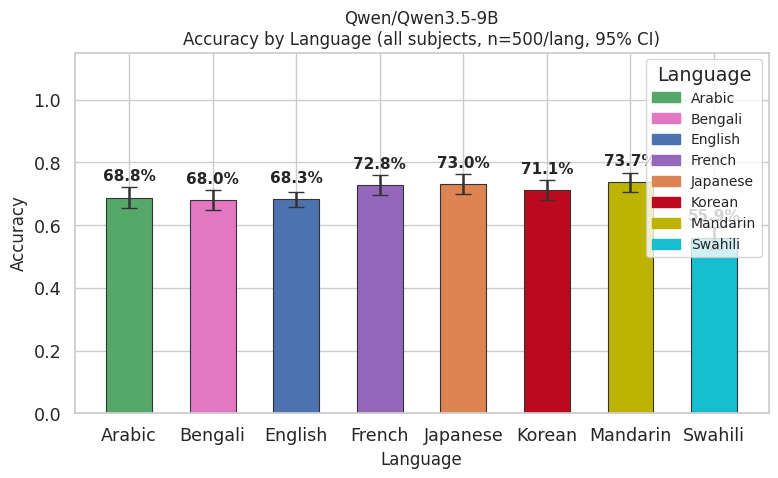

Saved → figures/accuracy_by_language.png


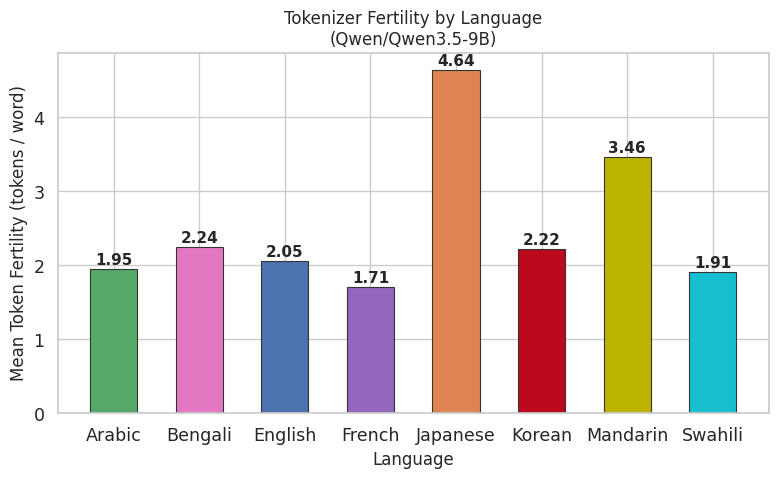

Saved → figures/token_fertility_by_language.png


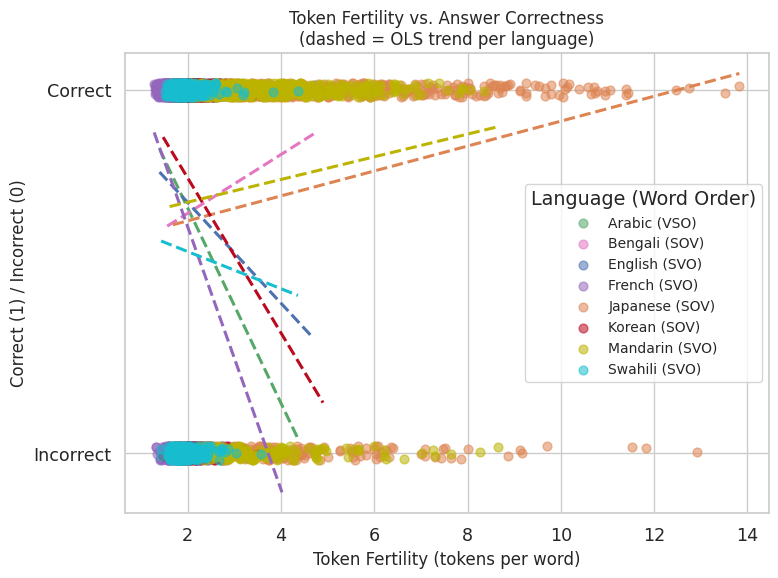

Saved → figures/fertility_vs_accuracy.png


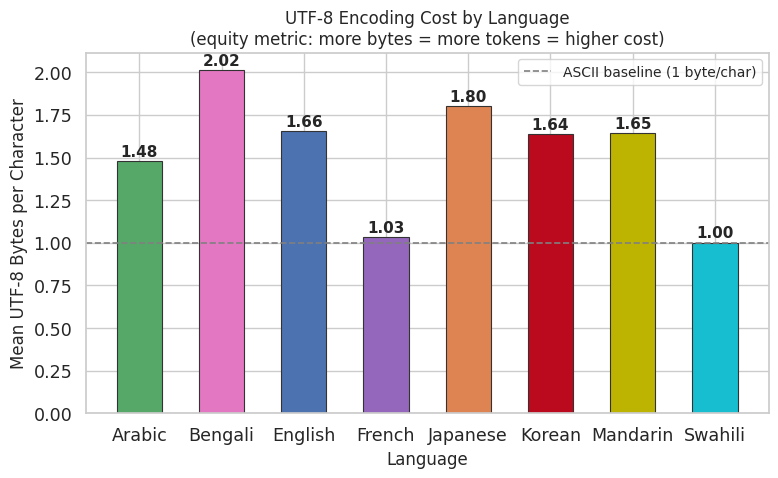

Saved → figures/bytes_per_char_by_language.png


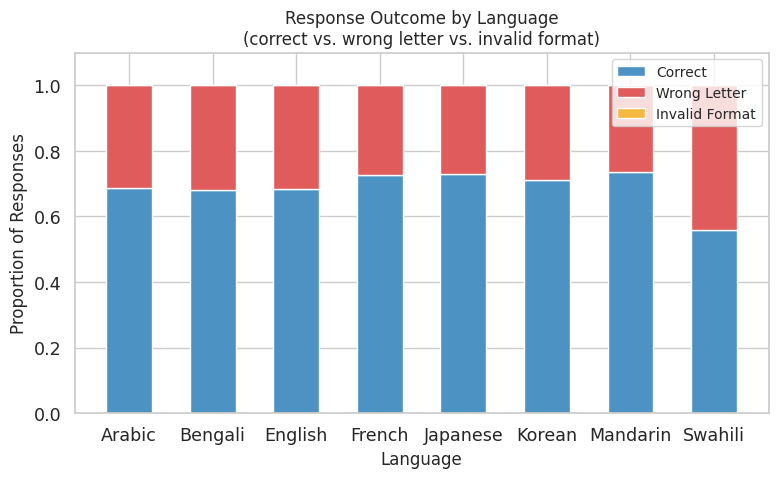

Saved → figures/failure_mode_breakdown.png


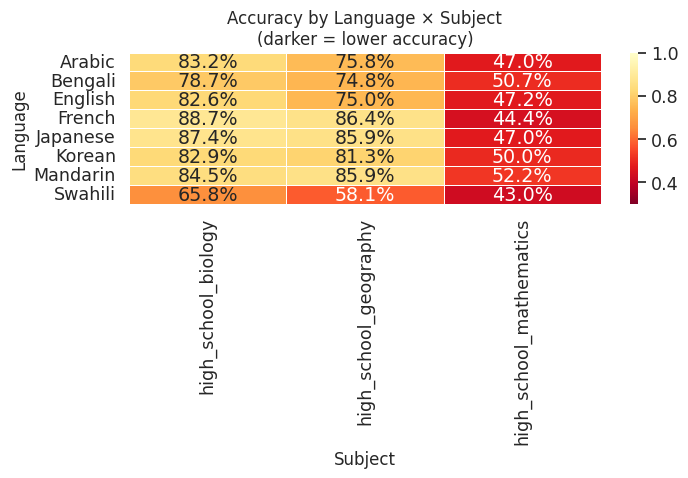

Saved → figures/accuracy_subject_heatmap.png


In [ ]:
sns.set_theme(style="whitegrid", font_scale=1.15)
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)


def language_color(lang: str) -> str:
    return LANG_COLORS.get(lang, "#999999")


def plot_accuracy_bar(summary: pd.DataFrame, save_path: Path) -> None:
    langs   = summary.index.tolist()
    accs    = summary["Accuracy"].values
    yerr_lo = accs - summary["CI Lower"].values
    yerr_hi = summary["CI Upper"].values - accs
    colors  = [language_color(l) for l in langs]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(langs, accs, color=colors,
                  yerr=[yerr_lo, yerr_hi], capsize=6,
                  error_kw={"elinewidth": 1.8, "ecolor": "#333333"},
                  width=0.55, edgecolor="#333333", linewidth=0.8)

    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(yerr_hi) + 0.01,
                f"{acc:.1%}", ha="center", va="bottom", fontsize=11, fontweight="bold")

    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Accuracy", fontsize=12)
    ax.set_xlabel("Language", fontsize=12)
    ax.set_title(f"{MODEL}\nAccuracy by Language (all subjects, n={SAMPLE_SIZE}/lang, 95% CI)", fontsize=12)

    patches = [mpatches.Patch(color=LANG_COLORS[l], label=l)
               for l in langs if l in LANG_COLORS]
    ax.legend(handles=patches, title="Language", loc="upper right", fontsize=10)

    plt.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")


plot_accuracy_bar(summary, FIGURE_DIR / "accuracy_by_language.png")


def plot_token_fertility_bar(summary: pd.DataFrame, save_path: Path) -> None:
    langs     = summary.index.tolist()
    fertility = summary["Mean Token Fertility"].values
    colors    = [language_color(l) for l in langs]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(langs, fertility, color=colors,
                  width=0.55, edgecolor="#333333", linewidth=0.8)

    for bar, val in zip(bars, fertility):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{val:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

    ax.set_ylabel("Mean Token Fertility (tokens / word)", fontsize=12)
    ax.set_xlabel("Language", fontsize=12)
    ax.set_title(f"Tokenizer Fertility by Language\n({MODEL})", fontsize=12)

    plt.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")


plot_token_fertility_bar(summary, FIGURE_DIR / "token_fertility_by_language.png")


def plot_fertility_vs_accuracy(df: pd.DataFrame, summary: pd.DataFrame, save_path: Path) -> None:
    fig, ax = plt.subplots(figsize=(8, 6))

    for lang, grp in df.groupby("language"):
        color = language_color(lang)
        order = summary.loc[lang, "Word Order"] if lang in summary.index else ""
        jitter = np.random.default_rng(42).uniform(-0.02, 0.02, size=len(grp))
        y_vals = grp["is_correct"].astype(float).values + jitter

        ax.scatter(grp["token_fertility"], y_vals, color=color,
                   alpha=0.55, s=40, label=f"{lang} ({order})")

        x = grp["token_fertility"].values.astype(float)
        y = grp["is_correct"].astype(float).values
        if x.std() > 0:
            m, b = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 50)
            ax.plot(x_line, m * x_line + b, color=color, linewidth=2.2, linestyle="--")

    ax.set_xlabel("Token Fertility (tokens per word)", fontsize=12)
    ax.set_ylabel("Correct (1) / Incorrect (0)", fontsize=12)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Incorrect", "Correct"])
    ax.set_title("Token Fertility vs. Answer Correctness\n(dashed = OLS trend per language)", fontsize=12)
    ax.legend(title="Language (Word Order)", fontsize=10, loc="center right")

    plt.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")


plot_fertility_vs_accuracy(results_df, summary, FIGURE_DIR / "fertility_vs_accuracy.png")


def plot_bytes_per_char(summary: pd.DataFrame, save_path: Path) -> None:
    """
    NEW: Bar chart of mean UTF-8 bytes per character by language.
    This is the equity metric — languages with higher bytes-per-char
    cost more tokens (and therefore more money/context) for the same
    informational content.
    """
    langs  = summary.index.tolist()
    bpc    = summary["Mean Bytes Per Char"].values
    colors = [language_color(l) for l in langs]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(langs, bpc, color=colors,
                  width=0.55, edgecolor="#333333", linewidth=0.8)

    for bar, val in zip(bars, bpc):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

    ax.axhline(1.0, color="gray", linestyle="--", linewidth=1.2, label="ASCII baseline (1 byte/char)")
    ax.set_ylabel("Mean UTF-8 Bytes per Character", fontsize=12)
    ax.set_xlabel("Language", fontsize=12)
    ax.set_title("UTF-8 Encoding Cost by Language\n(equity metric: more bytes = more tokens = higher cost)",
                 fontsize=12)
    ax.legend(fontsize=10)

    plt.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")


plot_bytes_per_char(summary, FIGURE_DIR / "bytes_per_char_by_language.png")


def plot_failure_mode_breakdown(summary: pd.DataFrame, save_path: Path) -> None:
    """
    NEW: Stacked bar chart showing proportion of correct / wrong_letter / invalid_format
    responses per language. Helps distinguish knowledge failures from format failures.
    """
    langs        = summary.index.tolist()
    correct_vals = summary["Accuracy"].values
    invalid_vals = summary["Invalid Rate"].values
    wrong_vals   = summary["Wrong Letter Rate"].values

    x = np.arange(len(langs))
    width = 0.55

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x, correct_vals, width, label="Correct",        color="#4C92C3")
    ax.bar(x, wrong_vals,   width, label="Wrong Letter",   color="#E05C5C",
           bottom=correct_vals)
    ax.bar(x, invalid_vals, width, label="Invalid Format", color="#F5B942",
           bottom=correct_vals + wrong_vals)

    ax.set_xticks(x)
    ax.set_xticklabels(langs)
    ax.set_ylabel("Proportion of Responses", fontsize=12)
    ax.set_xlabel("Language", fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.set_title("Response Outcome by Language\n(correct vs. wrong letter vs. invalid format)",
                 fontsize=12)
    ax.legend(fontsize=10, loc="upper right")

    plt.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")


plot_failure_mode_breakdown(summary, FIGURE_DIR / "failure_mode_breakdown.png")


def plot_subject_heatmap(subject_summary: pd.DataFrame, save_path: Path) -> None:
    """
    NEW: Heatmap of accuracy by (language x subject).
    Shows whether language gaps are consistent across domains.
    """
    pivot = subject_summary.pivot(index="Language", columns="Subject", values="Accuracy")

    fig, ax = plt.subplots(figsize=(max(6, len(MMLU_SUBJECTS) * 2.5), 5))
    sns.heatmap(pivot, annot=True, fmt=".1%", cmap="YlOrRd_r",
                linewidths=0.5, ax=ax, vmin=0.3, vmax=1.0)
    ax.set_title("Accuracy by Language × Subject\n(darker = lower accuracy)", fontsize=12)
    ax.set_xlabel("Subject", fontsize=12)
    ax.set_ylabel("Language", fontsize=12)

    plt.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")


plot_subject_heatmap(subject_summary, FIGURE_DIR / "accuracy_subject_heatmap.png")